<a href="https://colab.research.google.com/github/Phoenix121404/AirQualityPredictor/blob/main/MachineLearningAirQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the data


In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read the uploaded excel file into a pandas DataFrame
  try:
    df = pd.read_excel(fn)
    print("\nFile loaded successfully into a pandas DataFrame!")
    display(df.head())
  except Exception as e:
    print(f"Error loading file: {e}")

Saving AirQualityUCI.xlsx to AirQualityUCI.xlsx
User uploaded file "AirQualityUCI.xlsx" with length 1298197 bytes

File loaded successfully into a pandas DataFrame!


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


# Support Vector Machine

In [ ]:
import seaborn as sns
from sklearn import svm

df = df[df['C6H6(GT)'] != -200]   #remove placeholder missing value rows
df = df.replace(-200, np.nan)     #replace other -200 with NaN
df = df.dropna()                       # drop NaNs

#remove date/time columns
date_cols = ['Date', 'Time']
for col in date_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

#Target
y = df["C6H6(GT)"]

#Features
X = df.drop(columns=['C6H6(GT)'])

print("Features X:")
display(X.head())

print("Target y:")
display(y.head())

Features X:


,CO(GT),PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150.0,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2.0,1292.25,112.0,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2.2,1402.00,88.0,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2.2,1375.50,80.0,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,1.6,1272.25,51.0,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


Target y:


,C6H6(GT)
0,11.881723
1,9.397165
2,8.997817
3,9.228796
4,6.518224


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Features: ")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())
svr_model = SVR(kernel='rbf',epsilon=1)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained successfully.")


Shape of X_train: (578, 12)
Shape of X_test: (249, 12)
Shape of y_train: (578,)
Shape of y_test: (249,)
Scaled Training Features: 


,CO(GT),PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,-0.272146,0.259760,0.039669,-0.035825,-0.573578,-0.469788,-0.591338,0.177197,-0.293964,1.368548,-0.708646,1.000445
1,-0.272146,-0.453848,-0.448792,-0.060218,-0.306930,0.038668,-0.399121,-0.272288,-0.571980,0.300294,-0.765536,-0.644189
2,-1.188734,-1.286218,-0.951620,-1.520039,-1.300799,1.841630,-1.488349,-1.179552,-1.422238,-1.370161,1.232149,-0.264304
3,-0.906707,-1.244547,-0.712178,-1.045315,-1.022031,0.892326,-1.360204,-0.882106,-0.802622,-1.446963,0.981829,-0.620389
4,-0.483667,-0.020474,-0.602035,-0.087425,0.202125,-0.521195,-0.335049,0.538776,0.166696,0.059414,1.555615,2.730440


SVR model trained successfully.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#Make predictions on the scaled test set
y_pred_svr = svr_model.predict(X_test_scaled)

#Calculate evaluation metrics
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)
m_abse = mean_absolute_error(y_test, y_pred_svr)

#Print the evaluation metrics

print(f"SVR Mean Squared Error (MSE): {mse_svr:.4f}")
print(f"SVR R-squared (R2) Score: {r2_svr:.4f}")
print(f"SVR Mean Absolute Error: {m_abse:.4f}")

SVR Mean Squared Error (MSE): 3.6937
SVR R-squared (R2) Score: 0.9334
SVR Mean Absolute Error: 0.6810


/tmp/ipython-input-1796964313.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')


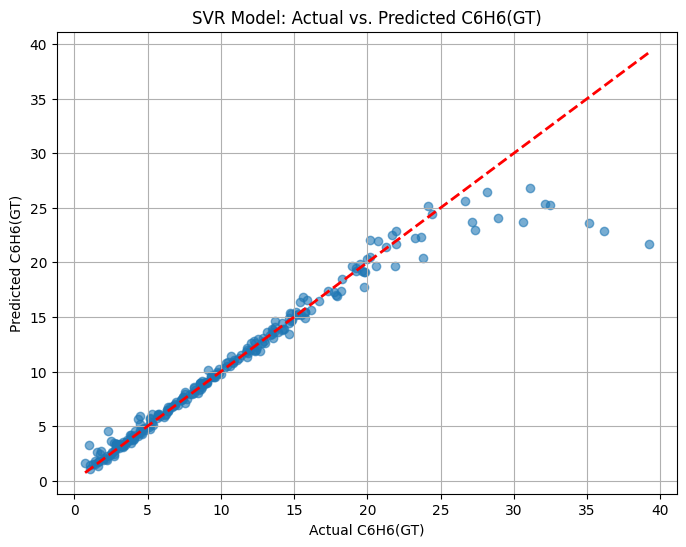

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.xlabel("Actual C6H6(GT)")
plt.ylabel("Predicted C6H6(GT)")
plt.title("SVR Model: Actual vs. Predicted C6H6(GT)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Features: ")
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())
svr_model = SVR(kernel='rbf', epsilon=1)
svr_model.fit(X_train_scaled, y_train)
print("SVR model trained successfully.")

#Display the hyperparameters of the SVR model
print("\nSVR Model Hyperparameters:")
display(svr_model.get_params())

print(f"SVR Mean Squared Error (MSE): {mse_svr:.4f}")
print(f"SVR R-squared (R2) Score: {r2_svr:.4f}")
print(f"SVR Mean Absolute Error: {m_abse:.4f}")

Shape of X_train: (578, 12)
Shape of X_test: (249, 12)
Shape of y_train: (578,)
Shape of y_test: (249,)
Scaled Training Features: 


,CO(GT),PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,-0.272146,0.259760,0.039669,-0.035825,-0.573578,-0.469788,-0.591338,0.177197,-0.293964,1.368548,-0.708646,1.000445
1,-0.272146,-0.453848,-0.448792,-0.060218,-0.306930,0.038668,-0.399121,-0.272288,-0.571980,0.300294,-0.765536,-0.644189
2,-1.188734,-1.286218,-0.951620,-1.520039,-1.300799,1.841630,-1.488349,-1.179552,-1.422238,-1.370161,1.232149,-0.264304
3,-0.906707,-1.244547,-0.712178,-1.045315,-1.022031,0.892326,-1.360204,-0.882106,-0.802622,-1.446963,0.981829,-0.620389
4,-0.483667,-0.020474,-0.602035,-0.087425,0.202125,-0.521195,-0.335049,0.538776,0.166696,0.059414,1.555615,2.730440


SVR model trained successfully.

SVR Model Hyperparameters:


{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 1,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

SVR Mean Squared Error (MSE): 3.6937
SVR R-squared (R2) Score: 0.9334
SVR Mean Absolute Error: 0.6810


# Random Forest Regression

In [ ]:
import pandas as pd

df = pd.read_excel('/content/AirQualityUCI.xlsx')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows of the DataFrame:
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       1092.00    122.0       1583.75      1203.25   
4         835.50    131.0       1205.00    116.0       1490.00      1110.00   

       T         RH        AH  
0  13.60  48.875001  0.757754  
1  13.30  47.700000  

In [ ]:
import numpy as np

# 1. Replace all occurrences of -200 with NaN
df_cleaned = df.replace(-200, np.nan)

# 2. Drop the 'Date' and 'Time' columns
df_cleaned = df_cleaned.drop(columns=['Date', 'Time'])

# 3. Remove any rows that contain NaN values
df_cleaned = df_cleaned.dropna()

# 4. Define the features (X) by selecting all columns except 'C6H6(GT)'
X = df_cleaned.drop(columns=['C6H6(GT)'])

# 5. Define the target variable (y) as the 'C6H6(GT)' column
y = df_cleaned['C6H6(GT)']

print("Shape of X (features):")
print(X.shape)
print("\nShape of y (target):")
print(y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 values of y:")
print(y.head())

Shape of X (features):
(827, 12)

Shape of y (target):
(827,)

First 5 rows of X:
   CO(GT)  PT08.S1(CO)  NMHC(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  \
0     2.6      1360.00     150.0        1045.50    166.0       1056.25   
1     2.0      1292.25     112.0         954.75    103.0       1173.75   
2     2.2      1402.00      88.0         939.25    131.0       1140.00   
3     2.2      1375.50      80.0         948.25    172.0       1092.00   
4     1.6      1272.25      51.0         835.50    131.0       1205.00   

   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)      T         RH        AH  
0    113.0       1692.00      1267.50  13.60  48.875001  0.757754  
1     92.0       1558.75       972.25  13.30  47.700000  0.725487  
2    114.0       1554.50      1074.00  11.90  53.975000  0.750239  
3    122.0       1583.75      1203.25  11.00  60.000000  0.786713  
4    116.0       1490.00      1110.00  11.15  59.575001  0.788794  

First 5 values of y:
0    11.881723
1     9.397165
2     8.99781

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training (30%) and testing (70%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (248, 12)
Shape of X_test: (579, 12)
Shape of y_train: (248,)
Shape of y_test: (579,)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize a new Random Forest Regressor model with random_state=42
new_model = RandomForestRegressor(random_state=42)

# Train the new model using the X_train and y_train from the new split
new_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully with the new data split.")

Random Forest Regressor model trained successfully with the new data split.


max_features=sqrt, depth=1, R²=0.7357
max_features=sqrt, depth=2, R²=0.9128
max_features=sqrt, depth=3, R²=0.9583
max_features=sqrt, depth=4, R²=0.9760
max_features=sqrt, depth=5, R²=0.9814
max_features=sqrt, depth=6, R²=0.9834


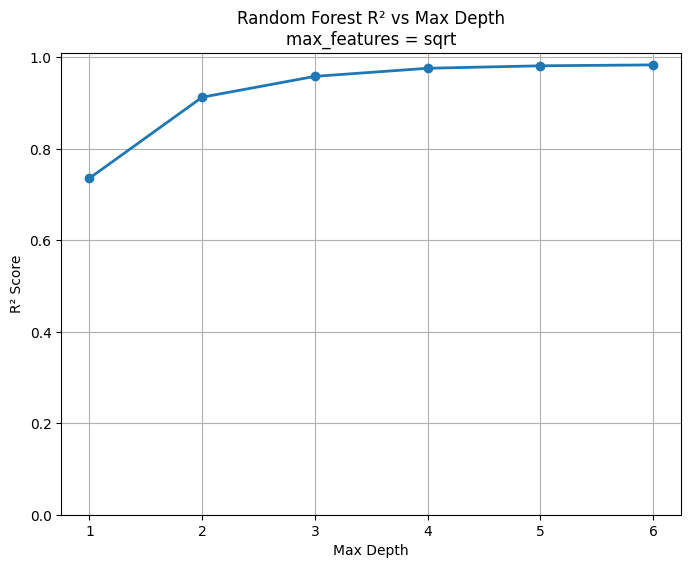

max_features=None, depth=1, R²=0.7042
max_features=None, depth=2, R²=0.9177
max_features=None, depth=3, R²=0.9774
max_features=None, depth=4, R²=0.9909
max_features=None, depth=5, R²=0.9928
max_features=None, depth=6, R²=0.9928


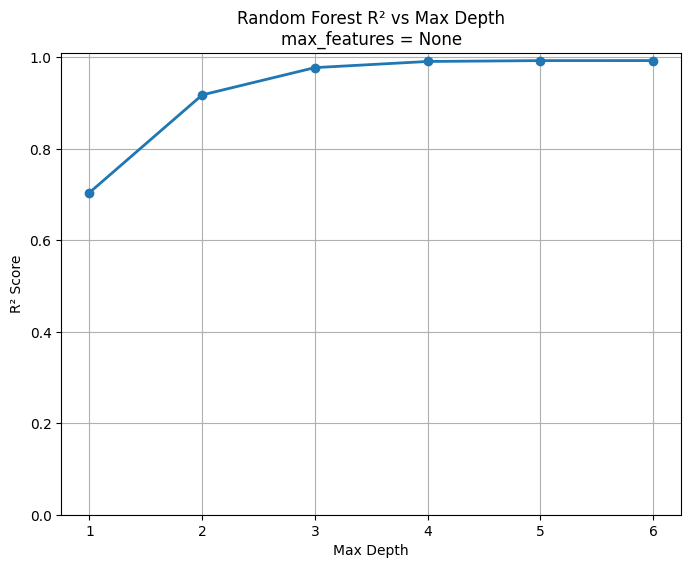

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

max_depth_values = range(1, 7)          # depths 1–6
max_features_options = ['sqrt', None]  # test both

for max_features in max_features_options:

    r2_scores = []  # store R² for this setting

    for depth in max_depth_values:

        # Train RF model
        rf = RandomForestRegressor(
            n_estimators=300,
            max_depth=depth,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # Predictions and R²
        y_pred = rf.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)

        print(f"max_features={max_features}, depth={depth}, R²={r2:.4f}")

    # Plot R² vs depth
    plt.figure(figsize=(8, 6))
    plt.plot(list(max_depth_values), r2_scores, marker='o', linewidth=2)
    plt.title(f"Random Forest R² vs Max Depth\nmax_features = {max_features}")
    plt.xlabel("Max Depth")
    plt.ylabel("R² Score")
    plt.xticks(list(max_depth_values))
    plt.grid(True)
    plt.ylim(0, 1.01)
    plt.show()


# Linear Regression

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split




# CLEAN THE DATA FIRST
df = df[df['C6H6(GT)'] != -200]   # remove placeholder missing-value rows
df = df.replace(-200, np.nan)     # replace other -200 with NaN
df = df.dropna()                  # drop rows that still contain NaN

# REMOVE DATE/TIME COLUMNS
date_cols = ['Date', 'Time']
for col in date_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

# Set target
y = df["C6H6(GT)"]

# Features
X = df.drop(columns=['C6H6(GT)'])

print("Features X:")
display(X.head())

print("Target y:")
display(y.head())

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)




Features X:


,CO(GT),PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150.0,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2.0,1292.25,112.0,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2.2,1402.00,88.0,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2.2,1375.50,80.0,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,1.6,1272.25,51.0,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


Target y:


,C6H6(GT)
0,11.881723
1,9.397165
2,8.997817
3,9.228796
4,6.518224


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² score:", r2)


RMSE: 0.6193477400185768
R² score: 0.9930788569856956


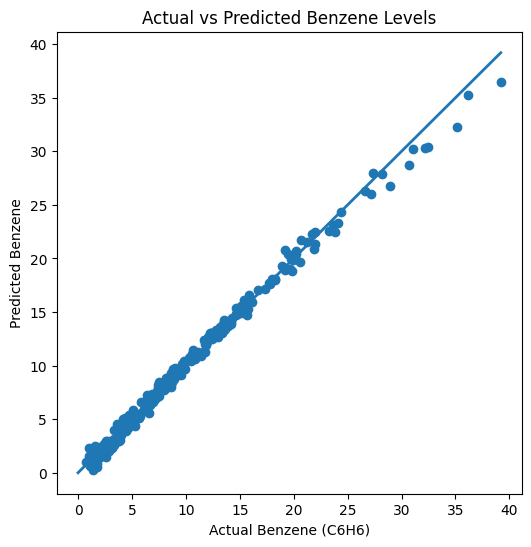

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([0,max(y_test)], [0,max(y_test)], linewidth=2)
plt.xlabel("Actual Benzene (C6H6)")
plt.ylabel("Predicted Benzene")
plt.title("Actual vs Predicted Benzene Levels")
plt.show()
